In [1]:
# Task 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Task 2: Load Dataset

df = pd.read_csv("adult_with_headers (1).csv")

print(df.head())

   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174             0              40   United-States   <=50

In [3]:
# Task 3: Display Dataset Information

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None


In [4]:
# Task 4: Statistical Summary

print(df.describe())

                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours_per_week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


In [5]:
# Task 5: Check Missing Values

print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [6]:
# Task 6: Handle Missing Values

df = df.replace(' ?', np.nan)

df = df.dropna()

print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [7]:
# Task 7: Identify Numerical and Categorical Columns

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print(numerical_columns)

print(categorical_columns)

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')
Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


In [8]:
# Task 8: Apply Standard Scaling

from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

df_standard_scaled = df.copy()

df_standard_scaled[numerical_columns] = standard_scaler.fit_transform(df[numerical_columns])

print(df_standard_scaled.head())

        age          workclass    fnlwgt   education  education_num  \
0  0.042796          State-gov -1.062722   Bachelors       1.128918   
1  0.880288   Self-emp-not-inc -1.007871   Bachelors       1.128918   
2 -0.033340            Private  0.244693     HS-grad      -0.439738   
3  1.108695            Private  0.425240        11th      -1.224066   
4 -0.794697            Private  1.406658   Bachelors       1.128918   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0      0.146092     -0.218

In [9]:
# Task 9: Apply Min-Max Scaling

from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax_scaled = df.copy()

df_minmax_scaled[numerical_columns] = minmax_scaler.fit_transform(df[numerical_columns])

print(df_minmax_scaled.head())

        age          workclass    fnlwgt   education  education_num  \
0  0.301370          State-gov  0.043338   Bachelors       0.800000   
1  0.452055   Self-emp-not-inc  0.047277   Bachelors       0.800000   
2  0.287671            Private  0.137244     HS-grad       0.533333   
3  0.493151            Private  0.150212        11th       0.400000   
4  0.150685            Private  0.220703   Bachelors       0.800000   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0       0.02174           

In [10]:
# Task 10: One-Hot Encoding for Columns with Less Than 5 Categories

low_category_columns = [
    col for col in categorical_columns
    if df[col].nunique() < 5
]

df_onehot = pd.get_dummies(df, columns=low_category_columns)

print(df_onehot.head())

   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race  \
0        Never-married        Adm-clerical   Not-in-family   White   
1   Married-civ-spouse     Exec-managerial         Husband   White   
2             Divorced   Handlers-cleaners   Not-in-family   White   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black   
4   Married-civ-spouse      Prof-specialty            Wife   Black   

   capital_gain  capital_loss  hours_per_week  native_country  sex_ Female  \
0          2174             0              40   United-States        False   
1             0             0         

In [11]:
# Task 11: Label Encoding for Columns with More Than 5 Categories

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_label = df.copy()

high_category_columns = [
    col for col in categorical_columns
    if df[col].nunique() >= 5
]

for col in high_category_columns:
    df_label[col] = label_encoder.fit_transform(df_label[col])

print(df_label.head())

   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          5   77516          9             13               4   
1   50          4   83311          9             13               2   
2   38          2  215646         11              9               0   
3   53          2  234721          1              7               2   
4   28          2  338409          9             13               2   

   occupation  relationship  race      sex  capital_gain  capital_loss  \
0           0             1     4     Male          2174             0   
1           3             0     4     Male             0             0   
2           5             1     4     Male             0             0   
3           5             0     2     Male             0             0   
4           9             5     2   Female             0             0   

   hours_per_week  native_country  income  
0              40              38   <=50K  
1              13              38   <=50

In [14]:
# Task 12: Create New Feature - Capital Difference

df['Capital_Difference'] = df['capital_gain'] - df['capital_loss']

print(df[['capital_gain', 'capital_loss', 'Capital_Difference']].head())

   capital_gain  capital_loss  Capital_Difference
0          2174             0                2174
1             0             0                   0
2             0             0                   0
3             0             0                   0
4             0             0                   0


In [16]:
# Task 13: Create New Feature - Hours Per Age

df['Hours_Per_Age'] = df['hours_per_week'] / df['age']

print(df[['hours_per_week', 'age', 'Hours_Per_Age']].head())

   hours_per_week  age  Hours_Per_Age
0              40   39       1.025641
1              13   50       0.260000
2              40   38       1.052632
3              40   53       0.754717
4              40   28       1.428571


In [17]:
# Task 14: Apply Log Transformation

df['Log_Age'] = np.log(df['age'])

print(df[['age', 'Log_Age']].head())

   age   Log_Age
0   39  3.663562
1   50  3.912023
2   38  3.637586
3   53  3.970292
4   28  3.332205


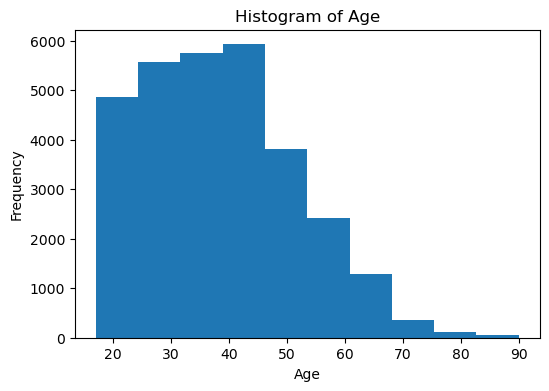

In [18]:
# Task 15: Histogram for Age

plt.figure(figsize=(6,4))

plt.hist(df['age'], bins=10)

plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

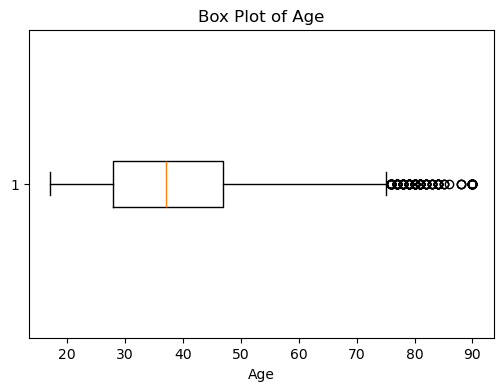

In [19]:
# Task 16: Box Plot for Age

plt.figure(figsize=(6,4))

plt.boxplot(df['age'].dropna(), vert=False)

plt.title("Box Plot of Age")
plt.xlabel("Age")

plt.show()